In [72]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
# Data Load
df = pd.read_csv('data/data.csv')

In [74]:
df.sample(5)

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
891,2/23/2015,Quarter4,sweing,Monday,7,0.75,30.10,709.0,6960,45,0.0,0,1,58.0,0.750770
1190,3/11/2015,Quarter2,sweing,Wednesday,6,0.70,23.41,1128.0,4560,40,0.0,0,1,38.0,0.700246
597,2/3/2015,Quarter1,finishing,Tuesday,6,0.70,2.90,NaN,960,0,0.0,0,0,8.0,0.495417
1186,3/11/2015,Quarter2,sweing,Wednesday,1,0.75,26.82,1322.0,7080,45,0.0,0,0,59.0,0.750051
1128,3/9/2015,Quarter2,finishing,Monday,11,0.80,2.90,NaN,0,960,0.0,0,0,8.0,0.960625


In [75]:
df.info()
# wip null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

In [76]:
df.describe()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437


In [77]:
len(df[df.duplicated])

0

In [78]:
for column_name in df.columns:
    print(column_name, df[column_name].dtype, df[column_name].unique())

date object ['1/1/2015' '1/3/2015' '1/4/2015' '1/5/2015' '1/6/2015' '1/7/2015'
 '1/8/2015' '1/10/2015' '1/11/2015' '1/12/2015' '1/13/2015' '1/14/2015'
 '1/15/2015' '1/17/2015' '1/18/2015' '1/19/2015' '1/20/2015' '1/21/2015'
 '1/22/2015' '1/24/2015' '1/25/2015' '1/26/2015' '1/27/2015' '1/28/2015'
 '1/29/2015' '1/31/2015' '2/1/2015' '2/2/2015' '2/3/2015' '2/4/2015'
 '2/5/2015' '2/7/2015' '2/8/2015' '2/9/2015' '2/10/2015' '2/11/2015'
 '2/12/2015' '2/14/2015' '2/15/2015' '2/16/2015' '2/17/2015' '2/18/2015'
 '2/19/2015' '2/22/2015' '2/23/2015' '2/24/2015' '2/25/2015' '2/26/2015'
 '2/28/2015' '3/1/2015' '3/2/2015' '3/3/2015' '3/4/2015' '3/5/2015'
 '3/7/2015' '3/8/2015' '3/9/2015' '3/10/2015' '3/11/2015']
quarter object ['Quarter1' 'Quarter2' 'Quarter3' 'Quarter4' 'Quarter5']
department object ['sweing' 'finishing ' 'finishing']
day object ['Thursday' 'Saturday' 'Sunday' 'Monday' 'Tuesday' 'Wednesday']
team int64 [ 8  1 11 12  6  7  2  3  9 10  5  4]
targeted_productivity float64 [0.8  0.75 0

In [84]:
list_cast_to_object = ["team"]
for column_name in list_cast_to_object:
    df[column_name] = df[column_name].astype(object)

In [79]:
df.isnull().sum().sort_values(ascending=False)
df['department'].replace("finishing ", "finishing", inplace=True)

C:\Users\TaeyoonKim\AppData\Local\Temp\ipykernel_6904\684468854.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['department'].replace("finishing ", "finishing", inplace=True)


In [80]:
df['department'].value_counts()

department
sweing       691
finishing    506
Name: count, dtype: int64

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

In [83]:
list_of_categorical = df.select_dtypes(include=['object']).columns.tolist()
list_of_numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist() # # include target column actual productivity
target_column = "actual_productivity"
list_of_numerical.remove(target_column)
print(len(df.columns))
print(len(list_of_categorical))
print(len(list_of_numerical))

15
4
10


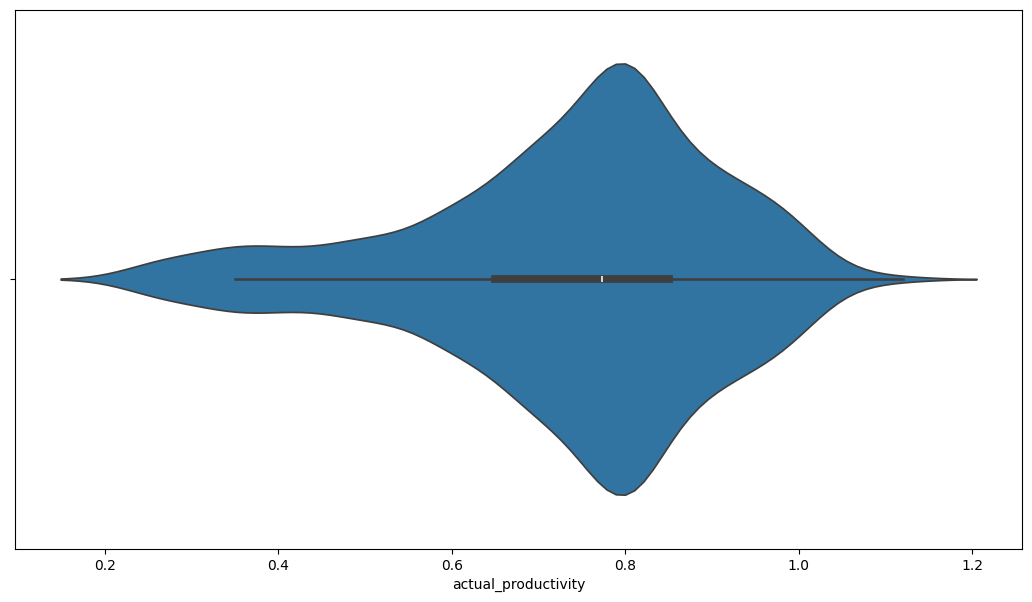

In [85]:
plt.figure(figsize=(13,7))
sns.violinplot(x=target_column, data=df)
plt.show()

In [87]:
from scipy.stats import skew
from scipy.stats import kurtosis


print(skew(df[target_column]))
print(kurtosis(df[target_column]))

-0.8064795276165394
0.3268286939395688


In [90]:
df[list_of_categorical].nunique().sort_values()

department     2
quarter        5
day            6
date          59
dtype: int64

In [91]:
df = df.drop("date", axis=1)
list_of_categorical.remove("date")

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   quarter                1197 non-null   object 
 1   department             1197 non-null   object 
 2   day                    1197 non-null   object 
 3   team                   1197 non-null   object 
 4   targeted_productivity  1197 non-null   float64
 5   smv                    1197 non-null   float64
 6   wip                    691 non-null    float64
 7   over_time              1197 non-null   int64  
 8   incentive              1197 non-null   int64  
 9   idle_time              1197 non-null   float64
 10  idle_men               1197 non-null   int64  
 11  no_of_style_change     1197 non-null   int64  
 12  no_of_workers          1197 non-null   float64
 13  actual_productivity    1197 non-null   float64
dtypes: float64(6), int64(4), object(4)
memory usage: 131.1+ 

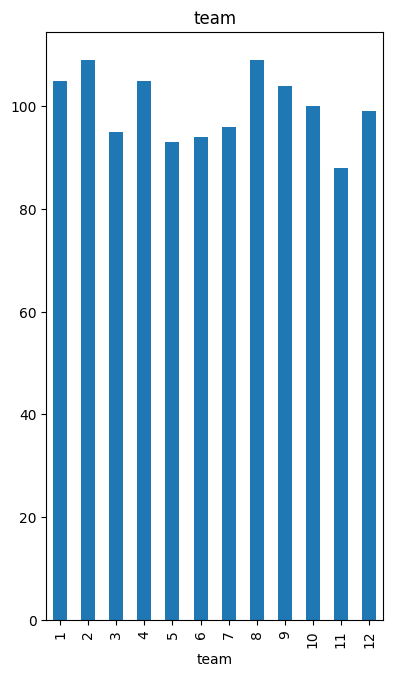

In [95]:
# cateogircla column 별 분포 확인 
plt.figure(figsize=(20,6))
x = 1
plt.subplots_adjust(top = 0.99, bottom=0.01, hspace=0.3, wspace=0.2)
for column_name in list_cast_to_object:
    plt.subplot(1,4,x)
    x = x+1
    df[column_name].value_counts().sort_index().plot(kind='bar')
    plt.title(column_name)
plt.show()

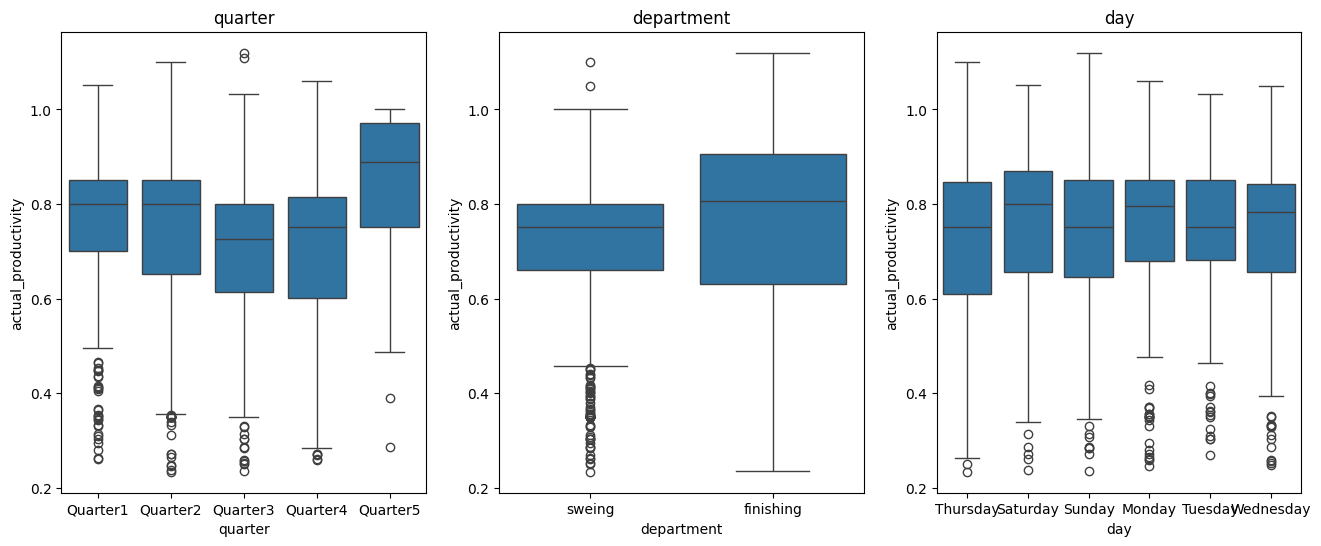

In [96]:
# categorical column과 dependent data(target column) 분포 분석
plt.figure(figsize=(16,16))
x = 1
plt.subplots_adjust(top = 0.99, bottom=0.01, hspace=0.2, wspace=0.2)
for column_name in list_of_categorical:
    plt.subplot(3,3,x)
    x = x+1
    sns.boxplot(data=df, x=column_name, y=target_column)
    plt.title(column_name)
plt.show()

# quarter마다 생산성 차이가 있음
# Team에 따른 생산성 차이는 variance가 큼

In [98]:
from scipy import stats

list_meaningful_cat_column_by_anova = []
for column_name in list_of_categorical:
    list_anova_data = []
    for item in df[column_name].unique():
        list_anova_data.append(df[df[column_name]==item][target_column])
    statistic, pvalue = stats.f_oneway(*list_anova_data)
    if pvalue <= 0.05:
        list_meaningful_cat_column_by_anova.append(column_name)
    print(column_name, ", ", statistic, ", ", pvalue)
        

quarter ,  7.11173497585018 ,  1.170397659389911e-05
department ,  9.246175421332591 ,  0.002411259977623153
day ,  0.7121012009422417 ,  0.614378842438619


In [105]:
from scipy.stats import kruskal

list_meaningful_column_by_kruskall = []

for column_name in list_of_categorical:
  list_kruskal = []
  for value in df[column_name].unique():
      df_tmp = df[df[column_name] == value][target_column].dropna()
      list_kruskal.append(np.array(df_tmp))
  statistic, pvalue = kruskal(*list_kruskal)
  if pvalue <= 0.05:
    list_meaningful_column_by_kruskall.append(column_name)
  print(column_name, ", ",statistic,", ", pvalue)
print("all numerical columns : ", len(list_of_categorical))
print("selected columns by anova : ", len(list_meaningful_column_by_kruskall), list_meaningful_column_by_kruskall)

quarter ,  38.30692437482908 ,  9.685158390050832e-08
department ,  27.288442517046633 ,  1.7525582757876983e-07
day ,  4.305541645652699 ,  0.5063147915119494
all numerical columns :  3
selected columns by anova :  2 ['quarter', 'department']


In [106]:
df[list_of_numerical].nunique().sort_values()

no_of_style_change         3
targeted_productivity      9
idle_men                  10
team                      12
idle_time                 12
incentive                 48
no_of_workers             61
smv                       70
over_time                143
wip                      548
dtype: int64

In [107]:
df[list_of_numerical].describe()

,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers
count,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858
std,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687
min,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000
50%,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000
75%,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000
max,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000


ValueError: num must be an integer with 1 <= num <= 9, not 10

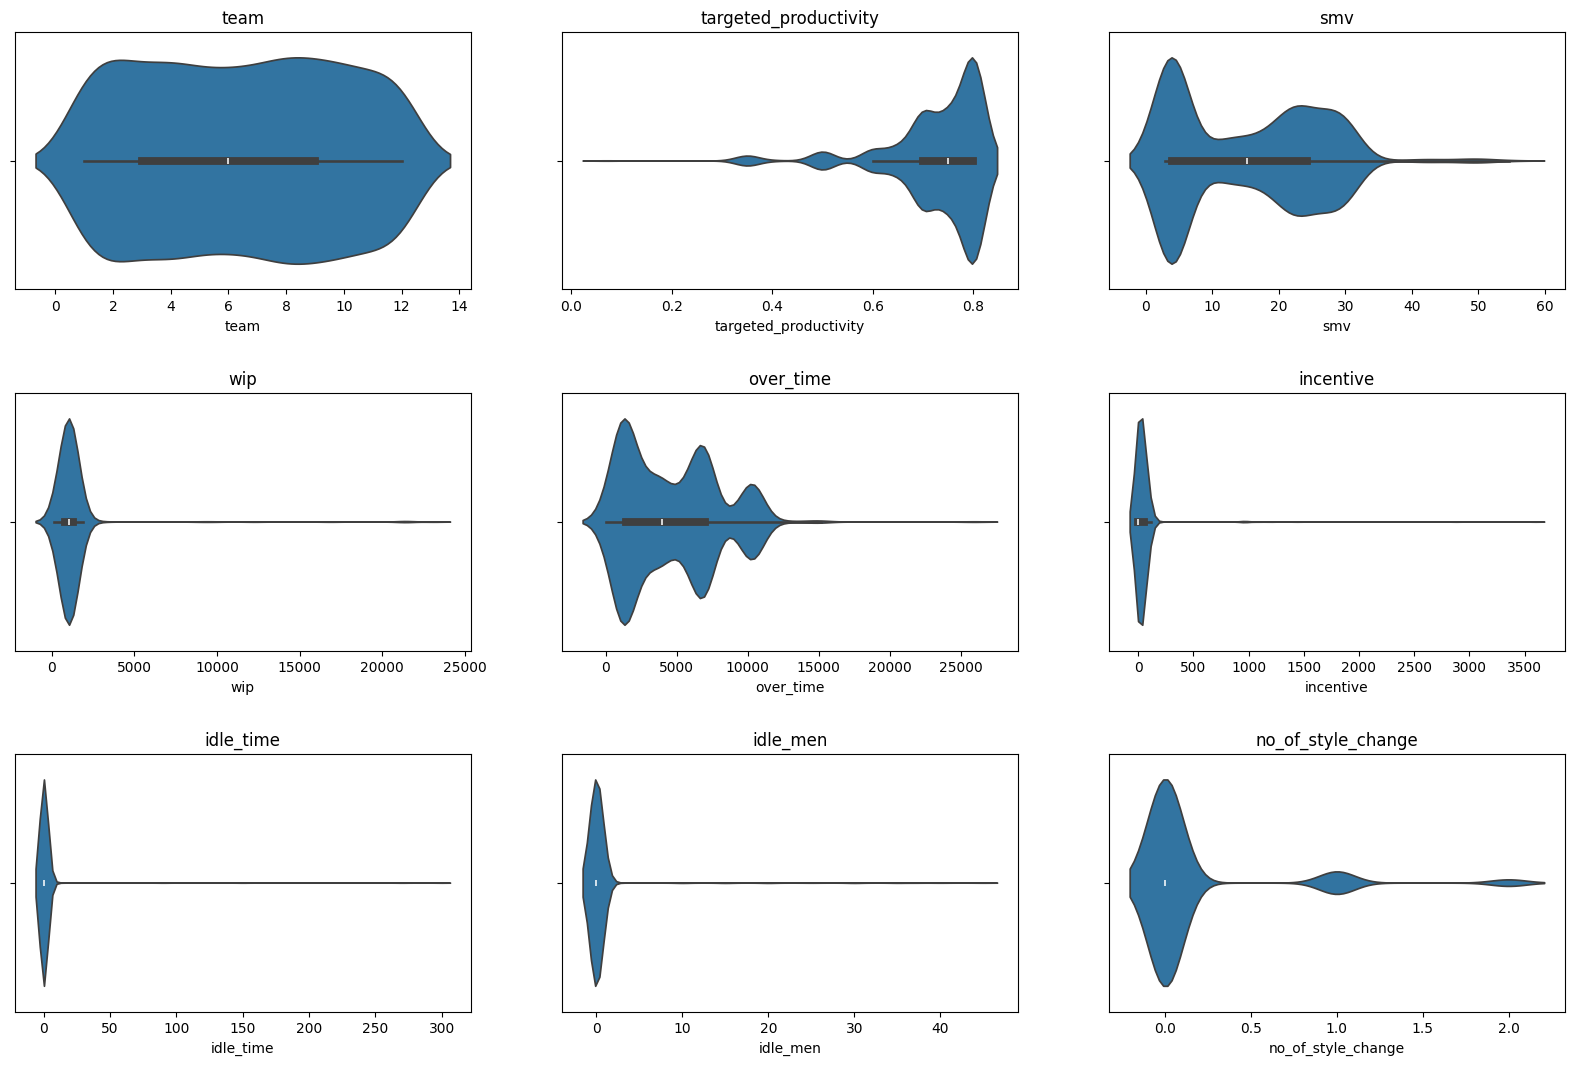

In [110]:
# numeric column 별 분포 확인
plt.figure(figsize=(20,10))
x = 1
plt.subplots_adjust(top = 0.99, bottom=0.01, hspace=0.4, wspace=0.2)
for column_name in list_of_numerical:
    plt.subplot(3,3,x)
    x = x+1
    sns.violinplot(x=column_name, data=df)
    plt.title(column_name)
plt.show()

In [ ]:
for column_name in list_of_numerical:
    print(column_name, "skew : ", skew(df[column_name].dropna()))

In [111]:
df_corr = df[list_of_numerical].corr()
df_corr

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers
team,1.000000,0.030274,-0.110011,-0.033474,-0.096737,-0.007674,0.003796,0.026974,-0.011194,-0.075113
targeted_productivity,0.030274,1.000000,-0.069489,0.062054,-0.088557,0.032768,-0.056181,-0.053818,-0.209294,-0.084288
smv,-0.110011,-0.069489,1.000000,-0.037837,0.674887,0.032629,0.056863,0.105901,0.315388,0.912176
wip,-0.033474,0.062054,-0.037837,1.000000,0.022302,0.167210,-0.026299,-0.048718,-0.072357,0.030383
over_time,-0.096737,-0.088557,0.674887,0.022302,1.000000,-0.004793,0.031038,-0.017913,0.059790,0.734164
incentive,-0.007674,0.032768,0.032629,0.167210,-0.004793,1.000000,-0.012024,-0.021140,-0.026607,0.049222
idle_time,0.003796,-0.056181,0.056863,-0.026299,0.031038,-0.012024,1.000000,0.559146,-0.011598,0.058049
idle_men,0.026974,-0.053818,0.105901,-0.048718,-0.017913,-0.021140,0.559146,1.000000,0.133632,0.106946
no_of_style_change,-0.011194,-0.209294,0.315388,-0.072357,0.059790,-0.026607,-0.011598,0.133632,1.000000,0.327787
no_of_workers,-0.075113,-0.084288,0.912176,0.030383,0.734164,0.049222,0.058049,0.106946,0.327787,1.000000


<Axes: >

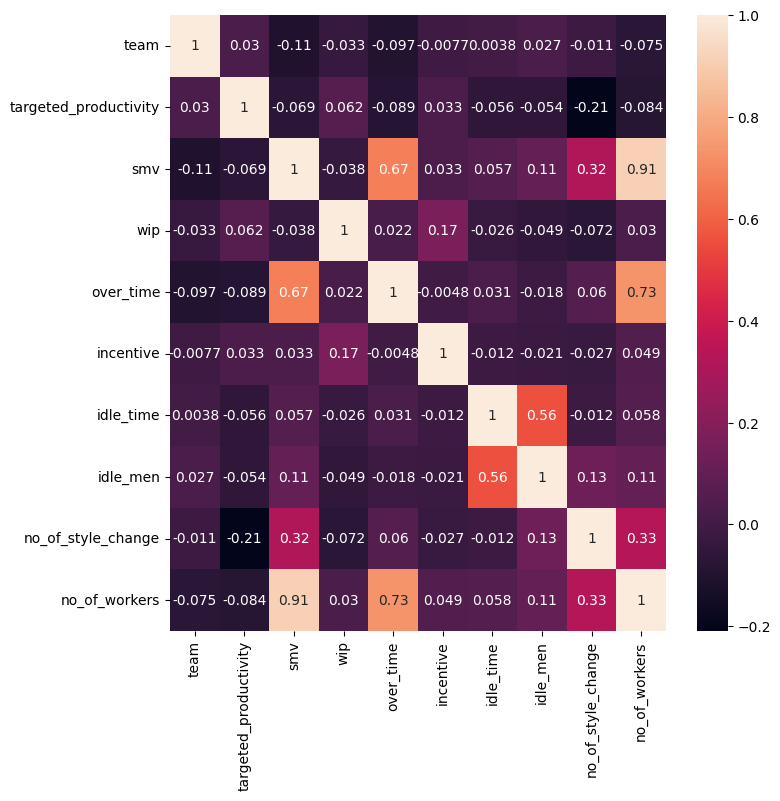

In [112]:
plt.figure(figsize=(8,8))
sns.heatmap(df_corr, annot=True)

In [113]:
# 너무 높은 correlation을 갖는 데이터를 삭제. 단, 해당 correlation값을 신뢰할 수 있는지 확인필요
index_corr_over_90 = np.where((abs(df_corr) > 0.9) & (df_corr != 1))
index_corr_over_90

(array([2, 9], dtype=int64), array([9, 2], dtype=int64))

In [114]:
len_corr_over_90 = len(index_corr_over_90[0])
left_columns = df_corr.columns[index_corr_over_90[0]]
right_columns = df_corr.columns[index_corr_over_90[1]]
for index in range(len_corr_over_90):
  print(left_columns[index], "<->", right_columns[index])  

smv <-> no_of_workers
no_of_workers <-> smv


In [115]:
# correlation이 0.9 이상인 경우의 pvalue 검정
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html
list_not_valid = []
for index in range(len_corr_over_90):
    statistic, pvalue = stats.pearsonr(df.loc[:,left_columns[index]], df.loc[:,right_columns[index]])
    print("%s<->%s : %f %f"%(left_columns[index],right_columns[index] , statistic, pvalue))
    if (pvalue > 0.05):
        list_not_valid.append(column_name)
print("end")
print(len(list_not_valid), " is not valids")

smv<->no_of_workers : 0.912176 0.000000
no_of_workers<->smv : 0.912176 0.000000
end
0  is not valids
